In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import json
from pathlib import Path
import os

In [2]:
print(Path.cwd())
os.chdir(Path.cwd().parent)
print(Path.cwd())

/Users/olejurgensen_uva/projects/KidsARC/KidsARC/_notebooks
/Users/olejurgensen_uva/projects/KidsARC/KidsARC


## Load items

In [3]:
with open("data/items/items_updated.json", "r") as f:
    existing_item_list = json.load(f)

In [4]:
existing_item_df = pd.DataFrame(existing_item_list)[["id", "concept", "xdim"]].rename(columns={"xdim": "size"})

counts = pd.crosstab(
    existing_item_df["concept"],
    existing_item_df["size"],
    margins=True,
    margins_name="total",
)
counts

size,3,5,total
concept,,,
clean_up,10,10,20
complete_shape,10,10,20
copy,10,10,20
crush,10,10,20
extend_to_boundary,9,11,20
extend_to_target,8,12,20
fill_in,8,12,20
foreground_and_background,10,10,20
horizontal_and_vertical,0,20,20


## Visualization

In [5]:
from utils.plot_utils import plot_matrix
from utils.prompt_utils import convert_to_array, get_d_matrix

def view_concept(items, concept, show_matrix=True):
    """One row per item: A, B, C, D_Concept (and the pixel-level D_Matrix)."""
    sel = [i for i in items if i.get('concept') == concept]
    if not sel:
        print(f"No items with concept '{concept}'")
        return
    cols = ['A', 'B', 'C', 'D_Concept'] + (['D_Matrix'] if show_matrix else [])
    fig, axes = plt.subplots(len(sel), len(cols),
                             figsize=(2.1 * len(cols), 2.1 * len(sel)),
                             squeeze=False)
    for r, item in enumerate(sel):
        print(item['id'])
        grids = {c: item[c] for c in cols if c in item}
        if show_matrix:
            grids['D_Matrix'] = get_d_matrix(item, 'pixel')
        for c, name in enumerate(cols):
            plot_matrix(convert_to_array(grids[name], item['xdim']),
                        title=name if r == 0 else '',
                        ax=axes[r][c], size=10)
        axes[r][0].set_ylabel(item['id'], rotation=0, ha='right',
                              va='center', fontsize=9)
    fig.suptitle(f"{concept}  ({len(sel)} items)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

2hmBPx
3m2VvG
69yHy7
8Kzzk2
aP9mhp
JBB0zi
m4YE3m
ScaQgX
vzyqo4
wcncOV
ZLuqmG
zmTsWK
dMhkM5
NQy7Jn
oRo06L
pFgSuz
QDfGeN
ToAPbe
zuZZ7g
tOWmE8


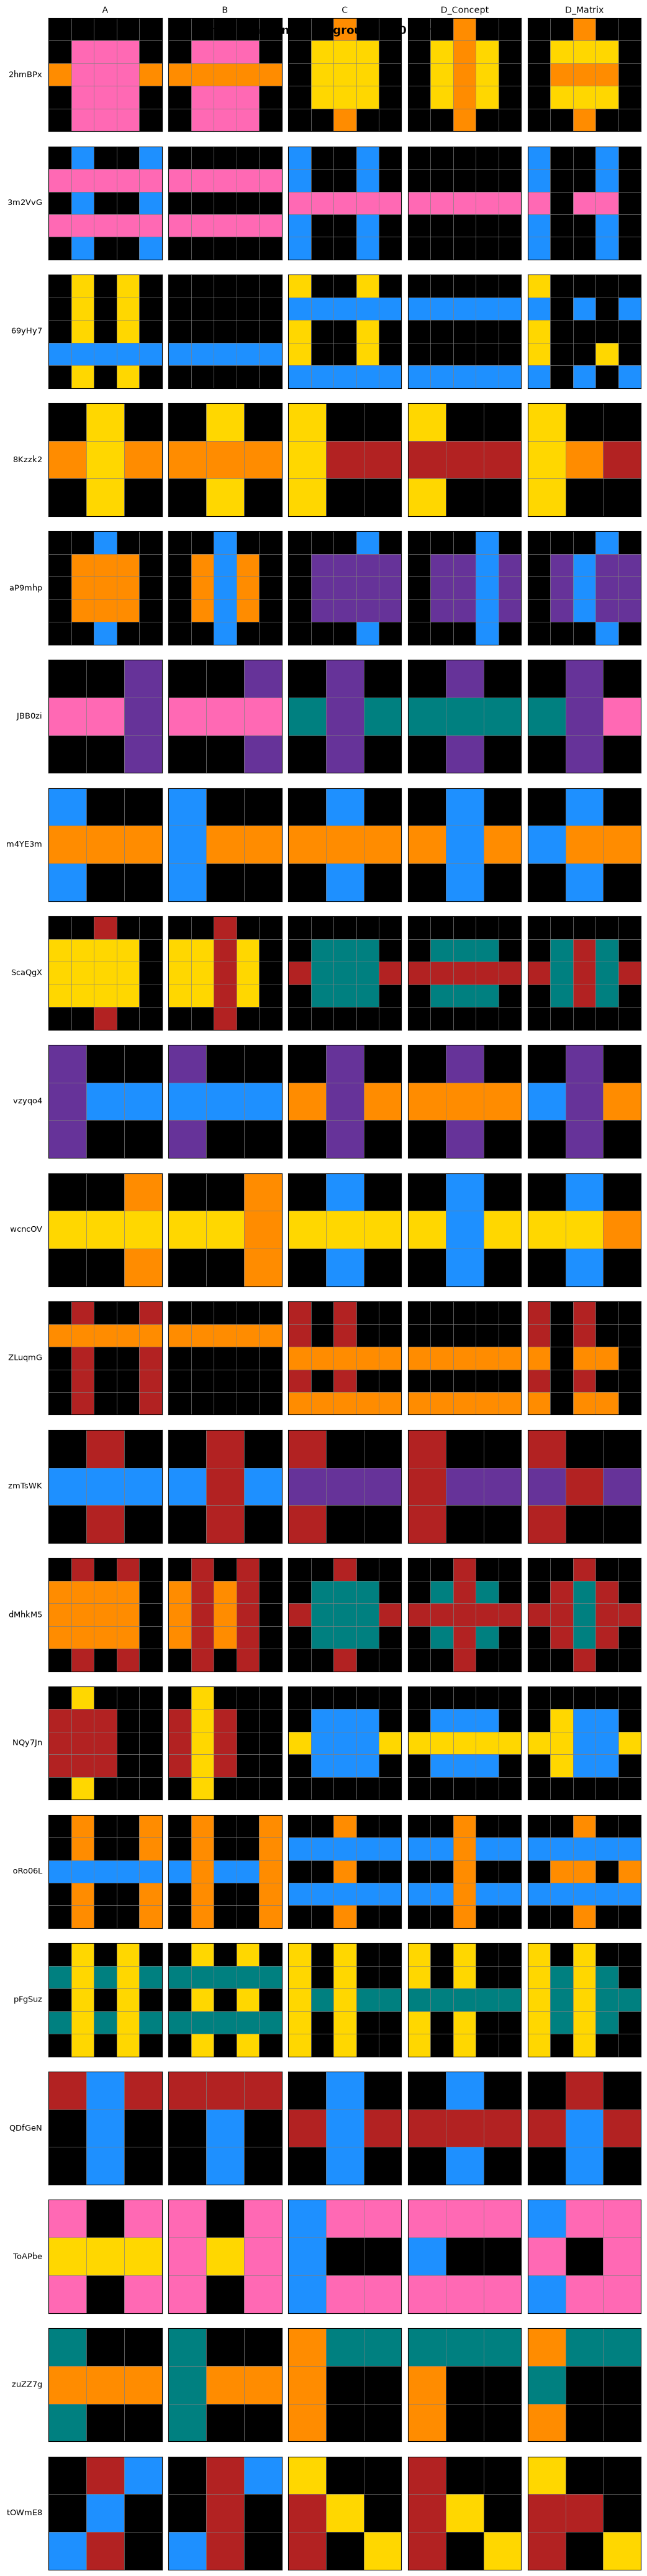

In [ ]:
view_concept(existing_item_list, 'foreground_and_background') # select category